<a href="https://colab.research.google.com/github/rafaelcasemiro01/rede_neural/blob/main/2_Predicao_Pima_Indians.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔮 Pima Indians Diabetes — Predição com Modelo Salvo
> **Disciplina:** Redes Neurais  |  **Plataforma:** Google Colab  |  **Autor:** Rafael Casemiro

Este notebook **carrega o modelo treinado** e realiza predições para novos pacientes.
O programa solicita os dados de entrada e exibe o diagnóstico com nível de risco.

---
## ⚠️ Pré-requisito
Execute o **Notebook 1 (Treinamento)** primeiro e faça upload do arquivo
`modelo_pima_mlp.joblib` na próxima célula.

## 📤 Célula 1 — Upload do Modelo Salvo
Faça upload do arquivo `modelo_pima_mlp.joblib` gerado pelo Notebook de Treinamento.

In [3]:
from google.colab import files
import joblib

print('📂 Selecione o arquivo modelo_pima_mlp.joblib...')
uploaded = files.upload()

# Carregar o modelo
NOME_ARQUIVO = 'modelo_pima_mlp.joblib'
pacote  = joblib.load(NOME_ARQUIVO)
modelo  = pacote['model']
scaler  = pacote['scaler']
features = pacote['feature_names']

print(f'\n✅ Modelo carregado com sucesso!')
print(f'   Acurácia do modelo : {pacote["acuracia"]*100:.1f}%')
print(f'   AUC-ROC            : {pacote["auc"]:.4f}')
print(f'   Épocas de treino   : {pacote["n_iter"]}')
print(f'   Features esperadas : {features}')

📂 Selecione o arquivo modelo_pima_mlp.joblib...


Saving modelo_pima_mlp.joblib to modelo_pima_mlp (1).joblib

✅ Modelo carregado com sucesso!
   Acurácia do modelo : 72.1%
   AUC-ROC            : 0.8154
   Épocas de treino   : 51
   Features esperadas : ['Gestacoes', 'Glicose', 'PressaoArterial', 'EspessuraPele', 'Insulina', 'IMC', 'LinhagemuDiabetes', 'Idade']


## 🧰 Célula 2 — Funções de Predição
Definimos as funções que processam os dados e exibem o resultado de forma clara.

In [4]:
import numpy as np

def classificar_risco(probabilidade):
    """Classifica o nível de risco com base na probabilidade."""
    if probabilidade < 0.20:
        return '🟢 BAIXO RISCO',      'Sem indicação de diabetes'
    elif probabilidade < 0.45:
        return '🟡 RISCO MODERADO',   'Monitoramento recomendado'
    elif probabilidade < 0.65:
        return '🟠 ALTO RISCO',       'Consulta médica urgente'
    elif probabilidade < 0.85:
        return '🔴 MUITO ALTO RISCO', 'Tratamento imediato recomendado'
    else:
        return '🚨 RISCO EXTREMO',    'Intervenção médica urgente'

def barra_risco(probabilidade, largura=30):
    """Gera uma barra visual de progresso."""
    preenchido = int(probabilidade * largura)
    vazio = largura - preenchido
    return f'[{"█" * preenchido}{"░" * vazio}] {probabilidade*100:.1f}%'

def fazer_predicao(dados, nome_paciente='Paciente'):
    """
    Realiza a predição para um paciente.
    dados: lista com 8 valores na ordem correta
    """
    X = np.array([dados])
    X_sc = scaler.transform(X)

    pred = modelo.predict(X_sc)[0]
    prob = modelo.predict_proba(X_sc)[0]
    prob_diabetes = prob[1]

    nivel, descricao = classificar_risco(prob_diabetes)

    print('\n' + '═' * 55)
    print(f'  {nome_paciente}')
    print('═' * 55)
    print(f'  Diagnóstico  : {"COM DIABETES" if pred==1 else "SEM DIABETES"}')
    print(f'  Nível de Risco: {nivel}')
    print(f'  Probabilidade: {barra_risco(prob_diabetes)}')
    print(f'  Orientação   : {descricao}')
    print('─' * 55)
    print(f'  Dados informados:')
    rotulos = ['Gestações', 'Glicose (OGTT)', 'Pressão Arterial',
               'Espessura Pele', 'Insulina', 'IMC',
               'Linhagem Diabetes', 'Idade']
    for rot, val in zip(rotulos, dados):
        print(f'    {rot:<20}: {val}')
    print('═' * 55)

    return pred, prob_diabetes

print('✅ Funções definidas!')

✅ Funções definidas!


## ⌨️ Célula 3 — Entrada Manual de Dados (Interativo)
O programa solicita os dados do paciente via `input()`. Digite os valores e pressione Enter.

In [6]:
def solicitar_dados():
    """Solicita os dados do paciente via input interativo."""
    print('\n' + '═' * 55)
    print('  ENTRADA DE DADOS DO PACIENTE')
    print('  (Pima Indians Diabetes Prediction)')
    print('═' * 55)

    campos = [
        ('Número de gestações',      'int',   (0, 20)),
        ('Glicose - OGTT (mg/dL)',   'float', (0, 300)),
        ('Pressão arterial (mmHg)',  'float', (0, 200)),
        ('Espessura da pele (mm)',   'float', (0, 100)),
        ('Insulina sérica (mu U/ml)','float', (0, 900)),
        ('IMC (kg/m²)',              'float', (0, 70)),
        ('Linhagem de diabetes',     'float', (0, 3)),
        ('Idade (anos)',             'int',   (1, 120)),
    ]

    nome = input('\n  Nome do paciente: ').strip() or 'Paciente'
    dados = []

    for i, (campo, tipo, (minv, maxv)) in enumerate(campos, 1):
        while True:
            try:
                val = input(f'  [{i}/8] {campo} [{minv}-{maxv}]: ')
                val = int(val) if tipo == 'int' else float(val)
                if minv <= val <= maxv:
                    dados.append(val)
                    break
                else:
                    print(f'       ⚠️  Valor fora do intervalo [{minv}, {maxv}]')
            except ValueError:
                print('       ⚠️  Digite um número válido')

    return nome, dados

# Executar
nome, dados = solicitar_dados()
fazer_predicao(dados, nome)


═══════════════════════════════════════════════════════
  ENTRADA DE DADOS DO PACIENTE
  (Pima Indians Diabetes Prediction)
═══════════════════════════════════════════════════════

  Nome do paciente: Letícia
  [1/8] Número de gestações [0-20]: 1
  [2/8] Glicose - OGTT (mg/dL) [0-300]: 200
  [3/8] Pressão arterial (mmHg) [0-200]: 100
  [4/8] Espessura da pele (mm) [0-100]: 30
  [5/8] Insulina sérica (mu U/ml) [0-900]: 400
  [6/8] IMC (kg/m²) [0-70]: 68
  [7/8] Linhagem de diabetes [0-3]: 1
  [8/8] Idade (anos) [1-120]: 29

═══════════════════════════════════════════════════════
  Letícia
═══════════════════════════════════════════════════════
  Diagnóstico  : COM DIABETES
  Nível de Risco: 🚨 RISCO EXTREMO
  Probabilidade: [████████████████████████████░░] 96.0%
  Orientação   : Intervenção médica urgente
───────────────────────────────────────────────────────
  Dados informados:
    Gestações           : 1
    Glicose (OGTT)      : 200.0
    Pressão Arterial    : 100.0
    Espessura Pe

(np.int64(1), np.float64(0.960081581973089))

## 🧪 Célula 4 — Teste com os 5 Pacientes do Projeto
Predições automáticas para os 5 pacientes definidos no enunciado da tarefa.

In [7]:
# Dados dos 5 pacientes do projeto
pacientes = [
    {
        'nome'       : 'Paciente 1 — BAIXO RISCO',
        'descricao'  : 'Jovem, poucos partos, glicose normal, IMC normal',
        'dados'      : [1, 89, 66, 23, 94, 28.1, 0.167, 21]
    },
    {
        'nome'       : 'Paciente 2 — RISCO MODERADO',
        'descricao'  : 'Idade média, múltiplos partos, glicose elevada, IMC elevado',
        'dados'      : [3, 120, 70, 30, 135, 35.3, 0.286, 35]
    },
    {
        'nome'       : 'Paciente 3 — ALTO RISCO',
        'descricao'  : 'Idade avançada, muitos partos, glicose muito elevada, IMC elevado',
        'dados'      : [6, 148, 72, 35, 188, 33.6, 0.627, 50]
    },
    {
        'nome'       : 'Paciente 4 — MUITO ALTO RISCO',
        'descricao'  : 'Idade avançada, muitos partos, glicose muito elevada, IMC muito elevado',
        'dados'      : [8, 175, 80, 40, 220, 38.5, 0.850, 55]
    },
    {
        'nome'       : 'Paciente 5 — RISCO EXTREMO',
        'descricao'  : 'Idade avançada, muitos partos, glicose extremamente elevada, IMC extremo',
        'dados'      : [10, 200, 90, 45, 250, 42.0, 1.200, 60]
    },
]

print('\n' + '█' * 55)
print('  PREDIÇÃO — 5 PACIENTES DO PROJETO FINAL')
print('  Modelo: MLP Pima Indians Diabetes')
print('█' * 55)

resultados = []
for p in pacientes:
    print(f'\n  Perfil: {p["descricao"]}')
    pred, prob = fazer_predicao(p['dados'], p['nome'])
    resultados.append({'nome': p['nome'], 'pred': pred, 'prob': prob})

# Resumo final
print('\n\n' + '═' * 55)
print('  RESUMO GERAL — TODOS OS PACIENTES')
print('═' * 55)
print(f'  {"Paciente":<30} {"Diagnóstico":<16} {"P(diabetes)":>12}')
print('  ' + '─' * 52)
for r in resultados:
    diag = 'COM DIABETES' if r['pred'] == 1 else 'Sem diabetes'
    nivel, _ = classificar_risco(r['prob'])
    print(f'  {r["nome"]:<30} {diag:<16} {r["prob"]*100:>10.1f}%')
print('═' * 55)


███████████████████████████████████████████████████████
  PREDIÇÃO — 5 PACIENTES DO PROJETO FINAL
  Modelo: MLP Pima Indians Diabetes
███████████████████████████████████████████████████████

  Perfil: Jovem, poucos partos, glicose normal, IMC normal

═══════════════════════════════════════════════════════
  Paciente 1 — BAIXO RISCO
═══════════════════════════════════════════════════════
  Diagnóstico  : SEM DIABETES
  Nível de Risco: 🟢 BAIXO RISCO
  Probabilidade: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.5%
  Orientação   : Sem indicação de diabetes
───────────────────────────────────────────────────────
  Dados informados:
    Gestações           : 1
    Glicose (OGTT)      : 89
    Pressão Arterial    : 66
    Espessura Pele      : 23
    Insulina            : 94
    IMC                 : 28.1
    Linhagem Diabetes   : 0.167
    Idade               : 21
═══════════════════════════════════════════════════════

  Perfil: Idade média, múltiplos partos, glicose elevada, IMC elevado

═════════

## 📈 Célula 5 — Visualização dos Resultados
Gráfico comparativo da probabilidade de diabetes para os 5 pacientes.

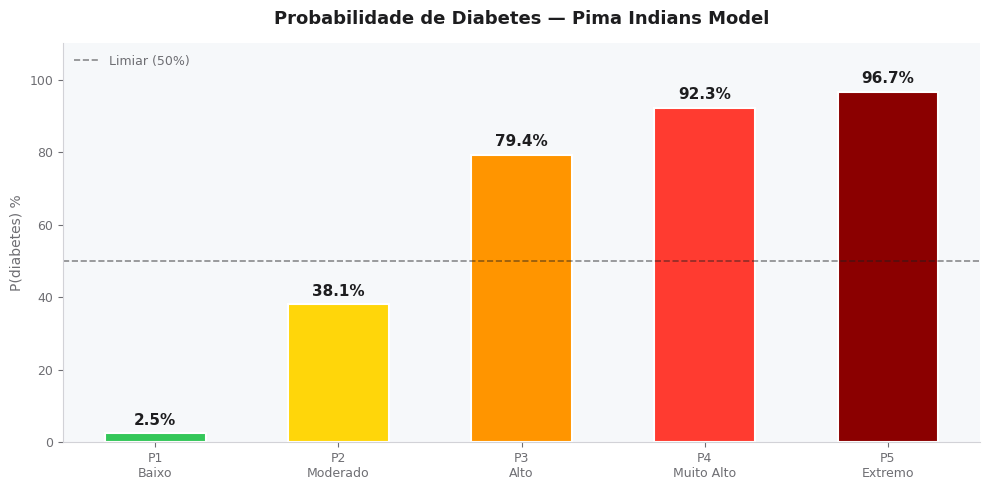

✅ Gráfico salvo: grafico_predicoes.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

nomes_curtos = ['P1\nBaixo', 'P2\nModerado', 'P3\nAlto', 'P4\nMuito Alto', 'P5\nExtremo']
probabilidades = [r['prob'] for r in resultados]
cores = ['#34C759', '#FFD60A', '#FF9500', '#FF3B30', '#8B0000']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F6F8FA')

barras = ax.bar(nomes_curtos, [p * 100 for p in probabilidades],
                color=cores, width=0.55, edgecolor='white', linewidth=1.5)

# Linha de referência 50%
ax.axhline(50, color='#1D1D1F', lw=1.2, ls='--', alpha=0.5, label='Limiar (50%)')

# Valores nas barras
for bar, prob in zip(barras, probabilidades):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{prob*100:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#1D1D1F')

ax.set_title('Probabilidade de Diabetes — Pima Indians Model',
             fontsize=13, fontweight='bold', color='#1D1D1F', pad=14)
ax.set_ylabel('P(diabetes) %', color='#6E6E73', fontsize=10)
ax.set_ylim(0, 110)
ax.set_yticks(range(0, 101, 20))
ax.tick_params(colors='#6E6E73', labelsize=9)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color('#D2D2D7')
ax.legend(frameon=False, labelcolor='#6E6E73', fontsize=9)

plt.tight_layout()
plt.savefig('grafico_predicoes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Gráfico salvo: grafico_predicoes.png')

## 🔄 Célula 6 — Modo Contínuo (Múltiplos Pacientes)
Digite dados de vários pacientes em sequência. Digite `sair` no nome para encerrar.

In [9]:
print('\n' + '═' * 55)
print('  MODO CONTÍNUO — MÚLTIPLOS PACIENTES')
print('  (Digite "sair" no nome para encerrar)')
print('═' * 55)

contador = 0
while True:
    contador += 1
    print(f'\n--- Paciente #{contador} ---')
    nome = input('  Nome do paciente (ou "sair"): ').strip()

    if nome.lower() in ['sair', 'exit', 'quit', 's', 'q']:
        print(f'\n✅ Encerrado. {contador-1} paciente(s) analisado(s).')
        break

    campos = [
        ('Gestações',              'int',   0,   20),
        ('Glicose OGTT (mg/dL)',   'float', 0,  300),
        ('Pressão Arterial (mmHg)','float', 0,  200),
        ('Espessura Pele (mm)',    'float', 0,  100),
        ('Insulina (mu U/ml)',     'float', 0,  900),
        ('IMC (kg/m²)',            'float', 0,   70),
        ('Linhagem Diabetes',      'float', 0,    3),
        ('Idade',                  'int',   1,  120),
    ]

    dados = []
    for campo, tipo, minv, maxv in campos:
        while True:
            try:
                val = input(f'  {campo} [{minv}-{maxv}]: ')
                val = int(val) if tipo == 'int' else float(val)
                if minv <= val <= maxv:
                    dados.append(val); break
                else:
                    print(f'  ⚠️ Valor entre {minv} e {maxv}')
            except ValueError:
                print('  ⚠️ Número inválido')

    fazer_predicao(dados, nome)


═══════════════════════════════════════════════════════
  MODO CONTÍNUO — MÚLTIPLOS PACIENTES
  (Digite "sair" no nome para encerrar)
═══════════════════════════════════════════════════════

--- Paciente #1 ---
  Nome do paciente (ou "sair"): sair

✅ Encerrado. 0 paciente(s) analisado(s).
